<a href="https://colab.research.google.com/github/hajyhia/Airbnb_Berlin_Price_predic/blob/main/Airbnb_Berlin_Price_Pedict_EDA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [205]:
# !pip install missingno
# !pip install geopy
# !pip install matplotlib

In [206]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# from pandas_profiling import ProfileReport
import numpy as np
import missingno as msno
sns.set()
# plt.style.use('ggplot')
plt.style.use('seaborn-v0_8')
import warnings
import datetime as dt

from sklearn import ensemble, tree, linear_model
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from scipy.stats import norm
from scipy import stats
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

# Ignore warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [207]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [208]:
df_EDA2 = pd.read_pickle('/content/drive/My Drive/Airbnb/df_EDA2.pkl')

In [209]:
df = df_EDA2.copy()
df.head()

,Listing ID,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Value Rating,review_date,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Neighbourhood Grouped,Property Type Reduced,Postal Code Reduced,Room Type Encoded,Property Type Reduced Encoded,Neighborhood Group Encoded,Postal Code Reduced Encoded,Host Response Time Encoded
0,2695,2.0,10.0,1.0,1.0,1.0,10.0,10.0,10.0,1.0,50.0,52.54851,9.0,13.40455,2.0,100.0,17.0,7.0,10.0,07-04-18,09-16-08,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Pankow,Apartment,10,1,0,6,0,1
1,3176,4.0,9.0,1.0,1.0,2.0,9.0,9.0,9.0,2.0,50.0,52.53500,10.0,13.41758,62.0,92.0,90.0,144.0,9.0,06-20-09,10-19-08,within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1
2,7071,2.0,10.0,1.0,1.0,2.0,10.0,10.0,10.0,1.0,100.0,52.54316,10.0,13.41509,2.0,96.0,33.0,229.0,10.0,08-18-09,05-16-09,within an hour,True,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Pankow,Apartment,10,1,0,6,0,3
3,9991,7.0,10.0,2.5,4.0,7.0,10.0,10.0,10.0,5.0,100.0,52.53303,10.0,13.41605,6.0,100.0,180.0,6.0,10.0,08-09-15,08-25-09,within a day,False,Prenzlauer Berg,Pankow,10405,False,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1
4,14325,1.0,10.0,1.0,0.0,1.0,9.0,10.0,10.0,1.0,100.0,52.54785,9.0,13.40556,90.0,93.0,70.0,23.0,9.0,06-29-10,11-18-09,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1


In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23460 entries, 0 to 23535
Data columns (total 38 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Listing ID                     23460 non-null  int64  
 1   Accomodates                    23460 non-null  float64
 2   Accuracy Rating                18862 non-null  float64
 3   Bathrooms                      23431 non-null  float64
 4   Bedrooms                       23440 non-null  float64
 5   Beds                           23426 non-null  float64
 6   Checkin Rating                 18844 non-null  float64
 7   Cleanliness Rating             18866 non-null  float64
 8   Communication Rating           18860 non-null  float64
 9   Guests Included                23460 non-null  float64
 10  Host Response Rate             12984 non-null  float64
 11  Latitude                       23460 non-null  float64
 12  Location Rating                18845 non-null  floa

## Declare data columns Lists

In [211]:
numerical_columns = ['Accomodates', 'Bathrooms', 'Bedrooms', 'Beds', 'Guests Included','Min Nights','Reviews','Price']
rating_columns = ['Value Rating','Location Rating', 'Cleanliness Rating','Checkin Rating','Accuracy Rating','Communication Rating','Host Response Rate','Overall Rating']
boolean_columns = ['Is Superhost','Is Exact Location', 'Instant Bookable']
categorical_columns = ['Room Type','Property Type Reduced','Neighborhood Group','Postal Code Reduced','Host Response Time'] # , 'Neighbourhood Grouped'
categorical_encoded_columns = ['Room Type Encoded','Property Type Reduced Encoded','Neighborhood Group Encoded','Postal Code Reduced Encoded','Host Response Time Encoded']
date_columns = ['review_date','Host Since']
geo_columns = ['Latitude','Longitude']
num_non_dummy_columns = numerical_columns + rating_columns + categorical_encoded_columns + geo_columns

In [212]:
df_num = df._get_numeric_data().dropna()
df_num = df_num.drop(columns=boolean_columns)
df_num.columns

Index(['Listing ID', 'Accomodates', 'Accuracy Rating', 'Bathrooms', 'Bedrooms',
       'Beds', 'Checkin Rating', 'Cleanliness Rating', 'Communication Rating',
       'Guests Included', 'Host Response Rate', 'Latitude', 'Location Rating',
       'Longitude', 'Min Nights', 'Overall Rating', 'Price', 'Reviews',
       'Value Rating', 'Room Type Encoded', 'Property Type Reduced Encoded',
       'Neighborhood Group Encoded', 'Postal Code Reduced Encoded',
       'Host Response Time Encoded'],
      dtype='object')

## Outliers

The box extends from the first quartile (Q1) to the third quartile (Q3) of the data, with a line at the median. The whiskers extend from the box to the farthest data point lying within 1.5x the inter-quartile range (IQR) from the box. Flier points are those past the end of the whiskers. See

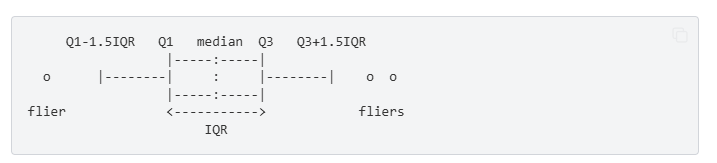

In [213]:
df_num_non_dummy = df[num_non_dummy_columns].copy()
df_num_non_dummy.shape

(23460, 23)

In [214]:
df_num.shape

(11503, 24)

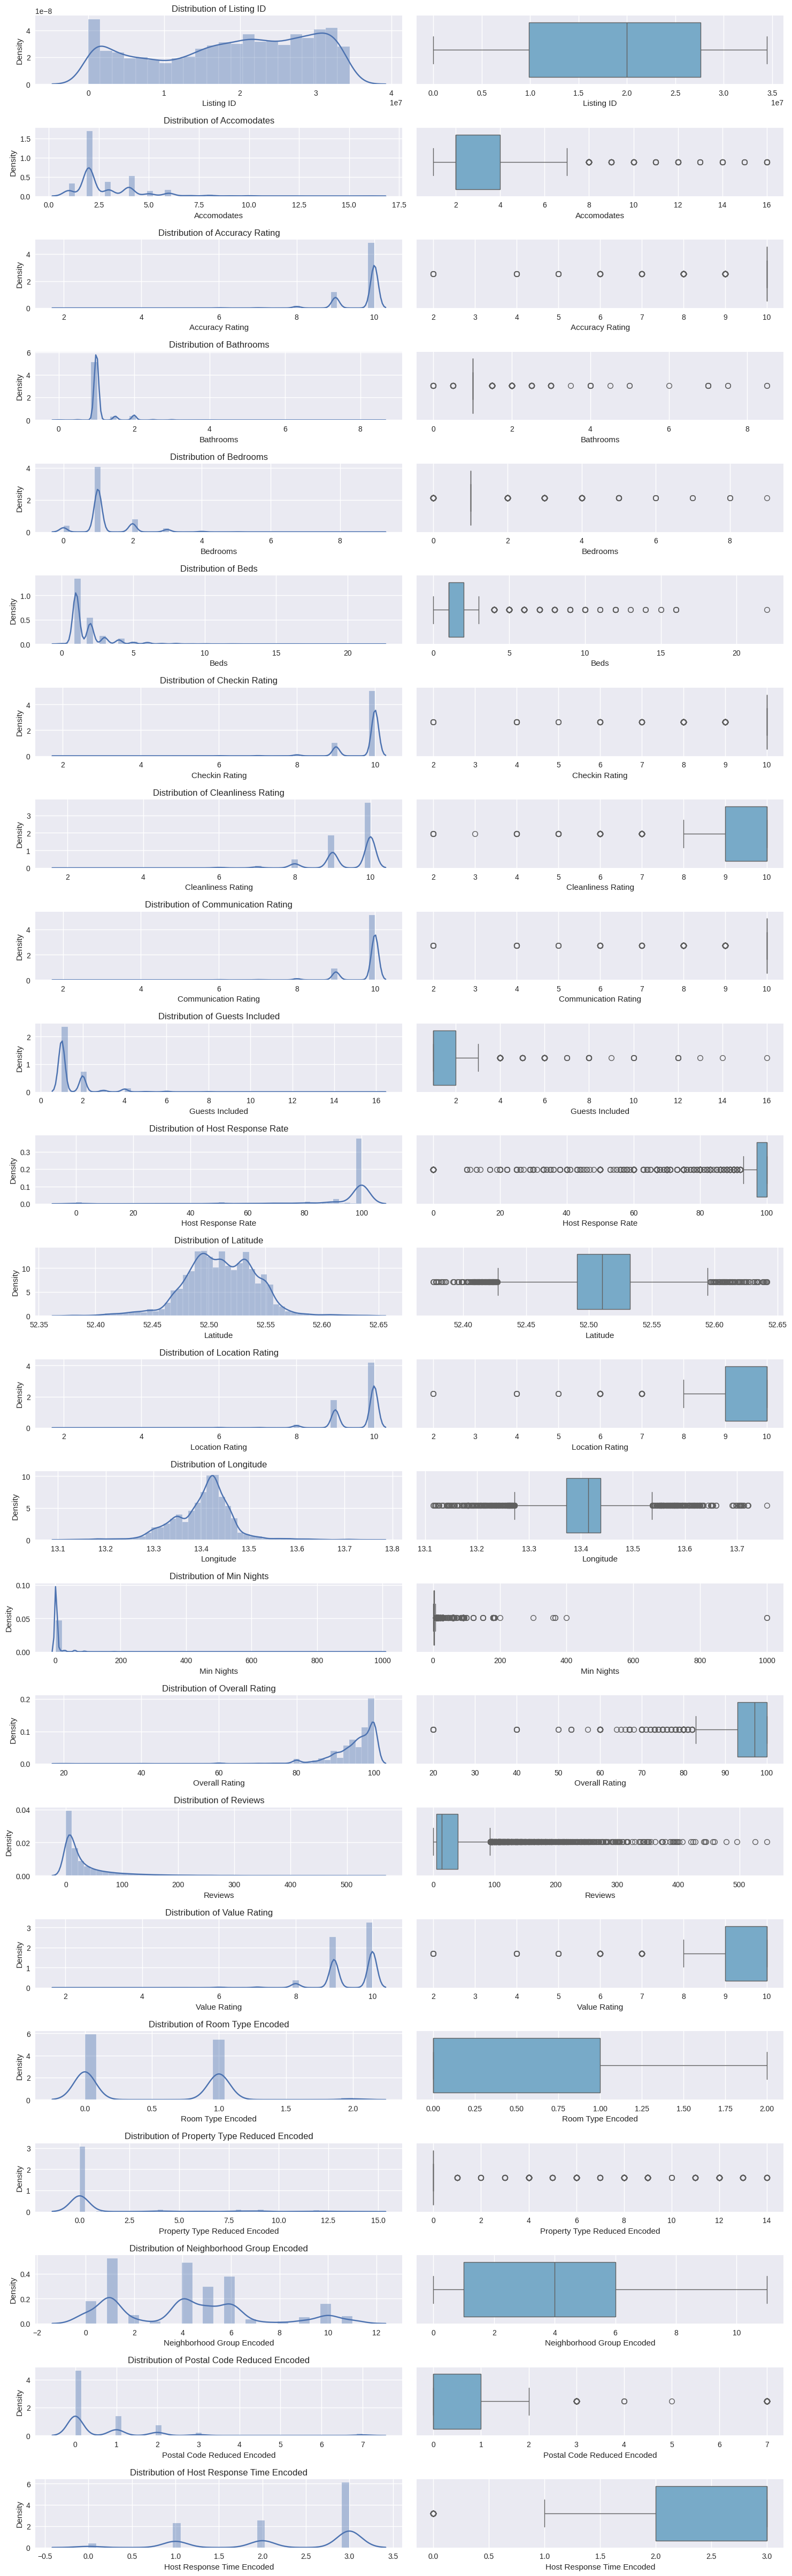

In [215]:
def outlier_boxplot(df):
  plt.figure(figsize=(15, 50))
  j = 1
  r = len(df.columns)
  for i, col in enumerate([c for c in df if c != 'Price'], 1):
    plt.subplot(r, 2, j)
    sns.distplot(df[col].dropna())
    plt.title(f'Distribution of {col}')
    plt.subplots_adjust(hspace = 0.6)

    plt.subplot(r, 2, j + 1)
    sns.boxplot(x=df[col].dropna(), palette='Blues')
    plt.subplots_adjust(hspace = 0.6)
    j = j + 2

  plt.tight_layout()
  plt.show()

outlier_boxplot(df_num)

In [216]:
# def outlier_boxplot(df, columns):
#   plt.figure(figsize=(14, 10))
#   for i, col in enumerate(columns, 1):
#   # for i, col in enumerate([c for c in numerical_columns if c not in ['Min Nights']], 1):
#     plt.subplot(5, 2, i)
#     sns.boxplot(x=df[col].dropna(), palette='Blues')
#     plt.subplots_adjust(hspace = 0.6)
#   plt.tight_layout()
#   plt.show()

# outlier_boxplot(df, numerical_columns)

The boxplots reveal potential outliers in several numerical features, particularly:

1. Price: Ignored as it is the target value
2. Reviews: Some listings have significantly higher review counts than others.
3. Bedrooms, Bathrooms, Beds, Accommodates: Some properties might have unrealistic values (e.g., too many or too few bedrooms relative to accommodations).

In [217]:
def df_describe(df, numerical_columns):
  min_vals = []
  max_vals = []
  Q1_ = []
  Q2_ = []
  Q3_ = []
  IQR_ = []
  lower_bound_ = []
  upper_bound_ = []
  for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q2 = df[column].quantile(0.50)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    min_vals.append(df[column].min())
    max_vals.append(df[column].max())
    Q1_.append(Q1)
    Q2_.append(Q2)
    Q3_.append(Q3)
    IQR_.append(IQR)
    lower_bound_.append(lower_bound)
    upper_bound_.append(upper_bound)

  # return pd.DataFrame(data = [min_vals, lower_bound_,Q1_,Q2_,Q3_ ,IQR_,upper_bound_,max_vals],
  #            columns=["min_vals", "lower_bound","Q1","Q2","Q3","IQR","upper_bound","max_vals"])
  return pd.DataFrame({
      'min': min_vals,
      'Q1(25%)': Q1_,
      'Q2(50%)': Q2_,
      'Q3(75%)': Q3_,
      'max': max_vals,
      'IQR': IQR_,
      'lower_bound': lower_bound_,
      'upper_bound': upper_bound_}, index=numerical_columns)

df_describe(df, numerical_columns + rating_columns)

,min,Q1(25%),Q2(50%),Q3(75%),max,IQR,lower_bound,upper_bound
Accomodates,1.0,2.0,2.0,3.0,16.0,1.0,0.5,4.5
Bathrooms,0.0,1.0,1.0,1.0,8.5,0.0,1.0,1.0
Bedrooms,0.0,1.0,1.0,1.0,10.0,0.0,1.0,1.0
Beds,0.0,1.0,1.0,2.0,22.0,1.0,-0.5,3.5
Guests Included,1.0,1.0,1.0,1.0,16.0,0.0,1.0,1.0
Min Nights,1.0,2.0,3.0,4.0,1000.0,2.0,-1.0,7.0
Reviews,0.0,1.0,5.0,17.0,545.0,16.0,-23.0,41.0
Price,1.0,31.0,49.0,74.0,600.0,43.0,-33.5,138.5
Value Rating,2.0,9.0,10.0,10.0,10.0,1.0,7.5,11.5
Location Rating,2.0,9.0,10.0,10.0,10.0,1.0,7.5,11.5


## missing values

In [218]:
df_nulls = df.copy()
for col in df_nulls:
    if df_nulls[col].isna().sum() == 0:
        del df_nulls[col]
df_nulls

,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Host Response Rate,Location Rating,Overall Rating,Value Rating,review_date,Host Since,Host Response Time
0,10.0,1.0,1.0,1.0,10.0,10.0,10.0,50.0,9.0,100.0,10.0,07-04-18,09-16-08,within a day
1,9.0,1.0,1.0,2.0,9.0,9.0,9.0,50.0,10.0,92.0,9.0,06-20-09,10-19-08,within a day
2,10.0,1.0,1.0,2.0,10.0,10.0,10.0,100.0,10.0,96.0,10.0,08-18-09,05-16-09,within an hour
3,10.0,2.5,4.0,7.0,10.0,10.0,10.0,100.0,10.0,100.0,10.0,08-09-15,08-25-09,within a day
4,10.0,1.0,0.0,1.0,9.0,10.0,10.0,100.0,9.0,93.0,9.0,06-29-10,11-18-09,within a day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,NaN,1.0,1.0,2.0,NaN,NaN,NaN,75.0,NaN,NaN,NaN,None,10-23-18,within a few hours
23532,NaN,1.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,05-13-19,None
23533,NaN,1.5,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,07-31-14,None
23534,NaN,1.0,3.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,05-13-19,None


<Axes: >

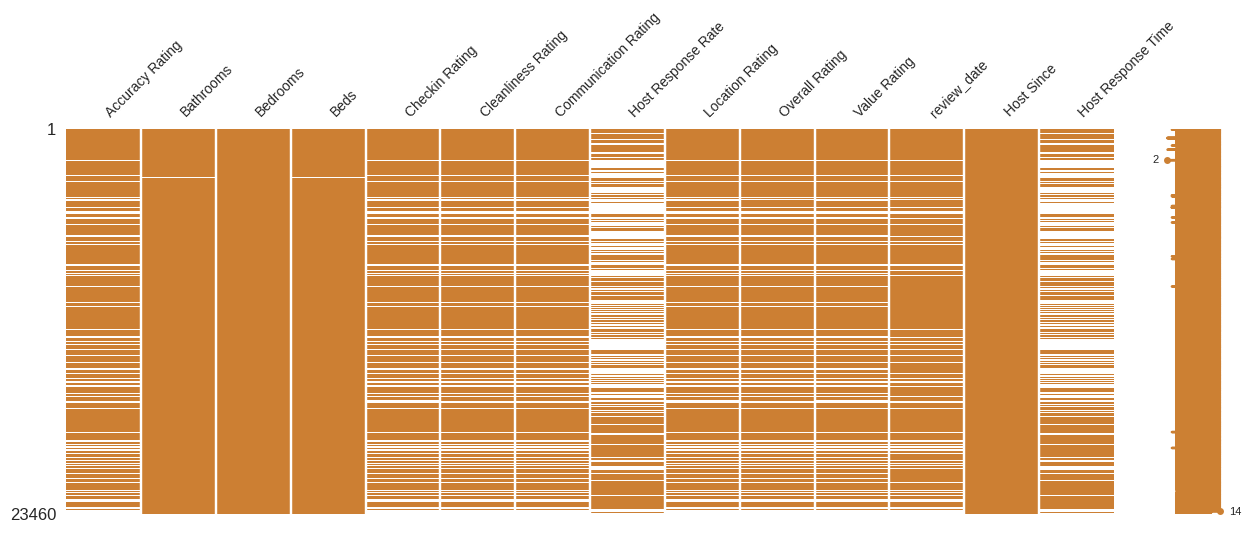

In [219]:
msno.matrix(df_nulls, figsize=(15, 5), fontsize=10, color=(0.8, 0.5, 0.2))

In [220]:
# df_nulls.isna().sum().sort_values(ascending=False)
missing_val = df_nulls.isna().sum()
missing_val_percent = 100 * df_nulls.isnull().sum() / len(df_nulls)
missing_val_table = pd.concat([missing_val, missing_val_percent], axis=1)
mis_val_table_ren_columns = missing_val_table.rename(columns = {0 : 'Missing Values', 1 : 'Missing Values Percent'})
mis_val_table_ren_columns = mis_val_table_ren_columns.sort_values('Missing Values Percent', ascending=False).round(2)
mis_val_table_ren_columns

,Missing Values,Missing Values Percent
Host Response Rate,10476,44.65
Host Response Time,10476,44.65
Value Rating,4618,19.68
Checkin Rating,4616,19.68
Location Rating,4615,19.67
Communication Rating,4600,19.61
Accuracy Rating,4598,19.60
Cleanliness Rating,4594,19.58
Overall Rating,4572,19.49
review_date,4108,17.51


If one of the rating columns value is missing, then the other rating columns values are missing two

<Axes: >

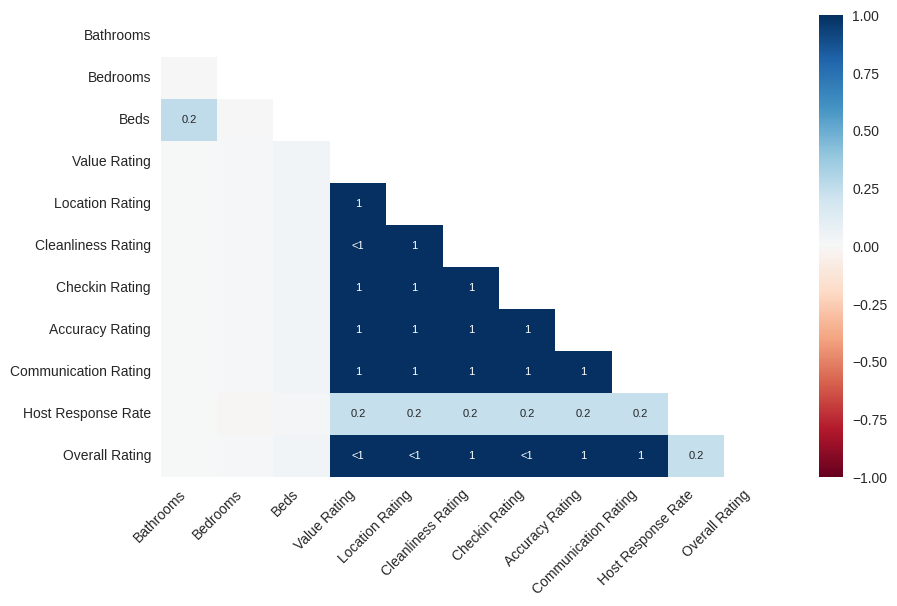

In [221]:
## missingness correlation heatmap
msno.heatmap(df_num_non_dummy,figsize=(10,6), fontsize=10)

## Checking correlations among numerical features

In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23460 entries, 0 to 23535
Data columns (total 38 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Listing ID                     23460 non-null  int64  
 1   Accomodates                    23460 non-null  float64
 2   Accuracy Rating                18862 non-null  float64
 3   Bathrooms                      23431 non-null  float64
 4   Bedrooms                       23440 non-null  float64
 5   Beds                           23426 non-null  float64
 6   Checkin Rating                 18844 non-null  float64
 7   Cleanliness Rating             18866 non-null  float64
 8   Communication Rating           18860 non-null  float64
 9   Guests Included                23460 non-null  float64
 10  Host Response Rate             12984 non-null  float64
 11  Latitude                       23460 non-null  float64
 12  Location Rating                18845 non-null  floa

In [223]:
numerical_df = df.select_dtypes(include=['int', 'float'])
correlation_matrix = numerical_df.corr(method = 'spearman')
correlation_matrix

,Listing ID,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Value Rating,Room Type Encoded,Property Type Reduced Encoded,Neighborhood Group Encoded,Postal Code Reduced Encoded,Host Response Time Encoded
Listing ID,1.000000,-0.011898,0.050635,-0.007870,-0.080409,-0.036436,0.045067,0.043684,0.051796,-0.081593,-0.018590,0.012343,0.091734,-0.009058,-0.096244,0.165362,0.014912,-0.271079,0.087278,0.061080,0.030418,-0.010446,0.016677,-0.174666
Accomodates,-0.011898,1.000000,-0.068347,0.156795,0.506295,0.718838,-0.040509,-0.025764,-0.046071,0.448686,0.049720,0.040085,-0.051158,-0.018343,0.008038,-0.089425,0.536043,0.144479,-0.143921,-0.459367,0.097283,0.010388,-0.045555,-0.091123
Accuracy Rating,0.050635,-0.068347,1.000000,0.006310,-0.015107,-0.094385,0.421688,0.439086,0.452027,-0.019735,0.067496,-0.010288,0.277268,0.007996,0.051160,0.504682,0.013267,0.020380,0.466973,0.003075,-0.016254,0.023385,0.003656,-0.021792
Bathrooms,-0.007870,0.156795,0.006310,1.000000,0.246021,0.181533,0.011782,0.006486,0.012124,0.090540,0.025502,0.002502,0.019550,-0.038940,0.034927,0.025882,0.134860,0.003685,0.006448,-0.007959,0.108463,-0.005159,-0.020376,-0.029129
Bedrooms,-0.080409,0.506295,-0.015107,0.246021,1.000000,0.526431,0.000829,0.024164,0.000601,0.267628,0.035641,0.004600,-0.020243,-0.010791,0.071826,0.002468,0.342409,0.041620,-0.035033,-0.227725,0.028483,0.028240,0.003581,-0.036816
Beds,-0.036436,0.718838,-0.094385,0.181533,0.526431,1.000000,-0.045640,-0.029026,-0.062302,0.372478,0.039136,0.028584,-0.071736,-0.036266,0.041228,-0.096480,0.414697,0.092888,-0.137571,-0.352985,0.134705,0.023762,-0.017760,-0.087497
Checkin Rating,0.045067,-0.040509,0.421688,0.011782,0.000829,-0.045640,1.000000,0.315407,0.530897,-0.008495,0.073366,-0.024226,0.233876,0.003390,0.017417,0.383175,0.013840,0.006039,0.346310,0.020630,0.016520,0.023201,0.021725,-0.022635
Cleanliness Rating,0.043684,-0.025764,0.439086,0.006486,0.024164,-0.029026,0.315407,1.000000,0.336250,0.019746,0.104863,0.005036,0.217219,-0.012711,0.012808,0.536756,0.109701,0.030925,0.414862,-0.044139,0.048289,0.033427,-0.006598,-0.061873
Communication Rating,0.051796,-0.046071,0.452027,0.012124,0.000601,-0.062302,0.530897,0.336250,1.000000,-0.008040,0.103405,-0.019167,0.254591,0.005967,0.032425,0.428698,0.024043,0.005321,0.370536,0.003264,-0.012157,0.021511,0.011635,-0.025161
Guests Included,-0.081593,0.448686,-0.019735,0.090540,0.267628,0.372478,-0.008495,0.019746,-0.008040,1.000000,0.063555,0.028408,-0.034317,0.003868,0.025692,-0.065424,0.380128,0.207210,-0.102300,-0.321135,0.060535,-0.002998,-0.058054,-0.091449


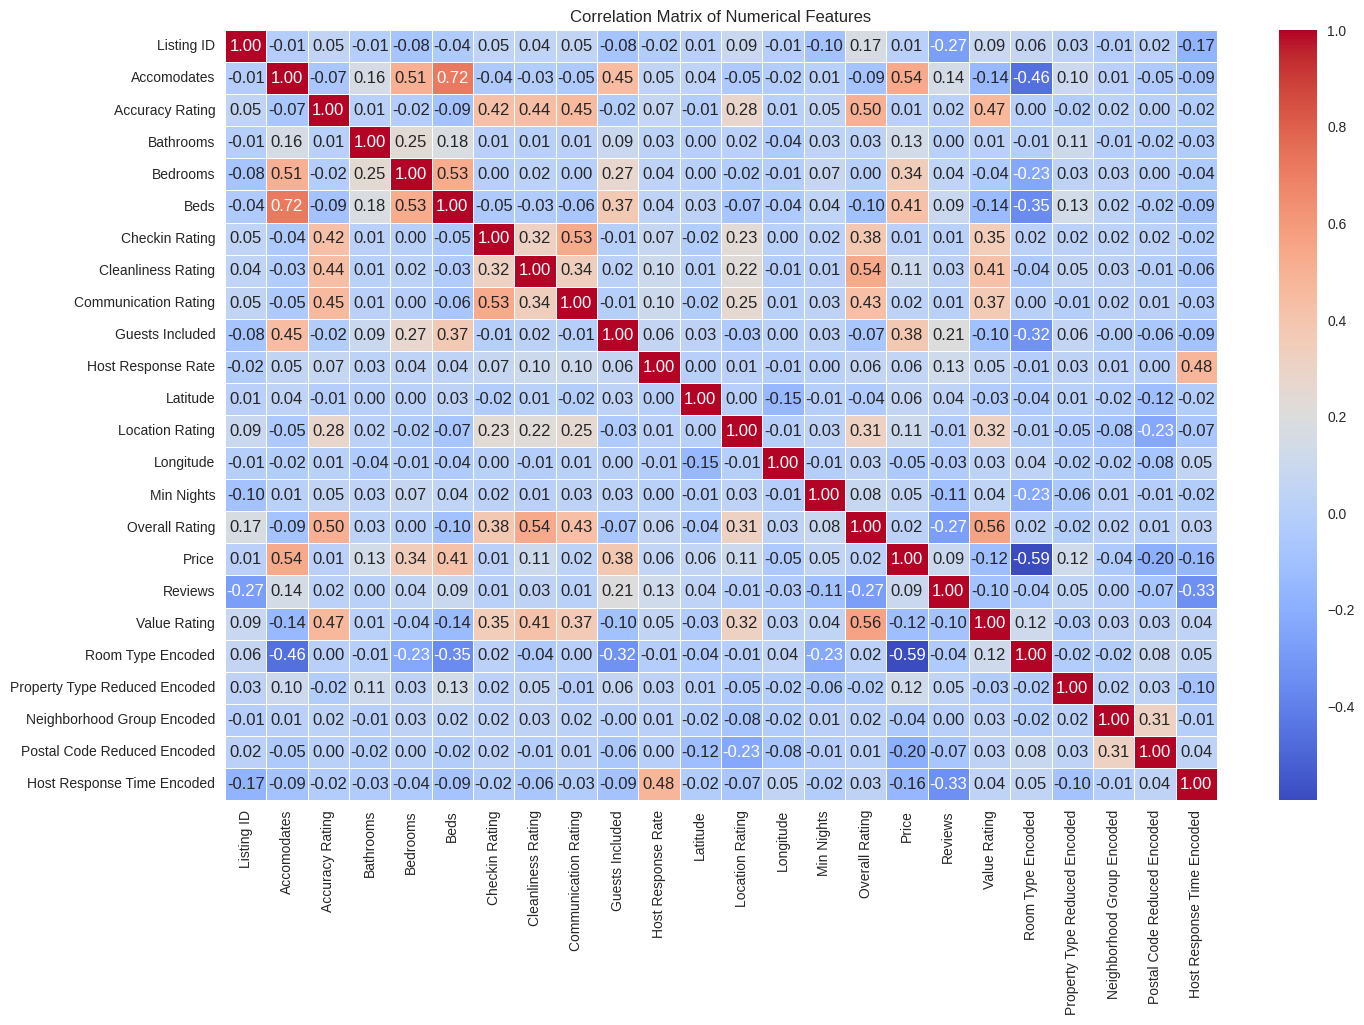

In [224]:
plt.figure(figsize=(16, 10))
numerical_df = df.select_dtypes(include=['int', 'float'])
# correlation_matrix = numerical_df.corr(method = 'spearman')
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
# plt.xticks(rotation=45)
plt.show()

## Data Cleansing

### outliers_df

Based on previous histograms and skewness visualizations, we can observe that the data is not normally distributed. To identify outliers, we will apply the IQR method, establishing boundaries before Q1 and after Q3. Any values falling outside these boundaries will be considered outliers.

In [225]:
def outliers_df(df):
    total_outliers = pd.DataFrame(columns=['Outlier count', 'Percent'])

    for col in df:  # Ensure processing numeric columns only
        temp = pd.DataFrame(df[col])
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        # Filter rows that are outliers in either direction
        temp_outliers = temp[(temp[col] > upper_limit) | (temp[col] < lower_limit)]
        num_outliers = len(temp_outliers)
        total_outliers.loc[col] = [num_outliers, num_outliers / len(df) * 100]

    return total_outliers[total_outliers['Percent'] > 0]

**Consider replacing outliers_df dataframe with only outliers_df_columns**

In [226]:
# Assume df_num_non_dummy is your DataFrame
# Call the function and sort results
outliers_df = outliers_df(df_num_non_dummy).sort_values('Percent', ascending=False)
outliers_df

,Outlier count,Percent
Bedrooms,5788.0,24.671782
Guests Included,5414.0,23.077579
Accuracy Rating,4357.0,18.572038
Checkin Rating,3697.0,15.758738
Communication Rating,3418.0,14.569480
Reviews,2980.0,12.702472
Bathrooms,2793.0,11.905371
Property Type Reduced Encoded,2546.0,10.852515
Min Nights,2514.0,10.716113
Host Response Rate,2181.0,9.296675


In [227]:
outliers_df.to_csv('/content/drive/My Drive/Airbnb/outliers_df.csv')

### new_df_outliers
Labeling every outlier with 'Outlier'

In [228]:
def outliers(df):
    label_out_df = df.copy()
    for col in label_out_df:
        if col in outliers_df.index:
            Q1 = label_out_df[col].quantile(0.25)
            Q3 = label_out_df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_limit = Q1 - 1.5 * IQR
            upper_limit = Q3 + 1.5 * IQR
            label_out_df[col] = np.where(label_out_df[col] > upper_limit,'Outlier',np.where(label_out_df[col] < lower_limit,'Outlier',label_out_df[col]))
    return label_out_df
new_df_outliers = outliers(df)
new_df_outliers.head(5)

,Listing ID,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Value Rating,review_date,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Neighbourhood Grouped,Property Type Reduced,Postal Code Reduced,Room Type Encoded,Property Type Reduced Encoded,Neighborhood Group Encoded,Postal Code Reduced Encoded,Host Response Time Encoded
0,2695,2.0,10.0,1.0,1.0,1.0,10.0,10.0,10.0,1.0,Outlier,52.54851,9.0,13.40455,2.0,100.0,17.0,7.0,10.0,07-04-18,09-16-08,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Pankow,Apartment,10,1,0,6,0,1
1,3176,4.0,Outlier,1.0,1.0,2.0,Outlier,9.0,Outlier,Outlier,Outlier,52.535,10.0,13.41758,Outlier,92.0,90.0,Outlier,9.0,06-20-09,10-19-08,within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1
2,7071,2.0,10.0,1.0,1.0,2.0,10.0,10.0,10.0,1.0,100.0,52.54316,10.0,13.41509,2.0,96.0,33.0,Outlier,10.0,08-18-09,05-16-09,within an hour,True,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Pankow,Apartment,10,1,0,6,0,3
3,9991,Outlier,10.0,Outlier,Outlier,Outlier,10.0,10.0,10.0,Outlier,100.0,52.53303,10.0,13.41605,6.0,100.0,Outlier,6.0,10.0,08-09-15,08-25-09,within a day,False,Prenzlauer Berg,Pankow,10405,False,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1
4,14325,1.0,10.0,1.0,Outlier,1.0,Outlier,10.0,10.0,1.0,100.0,52.54785,9.0,13.40556,Outlier,93.0,70.0,23.0,9.0,06-29-10,11-18-09,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1


### df_outliers

Creating a dataframe with outliers as 1 and non-outliers as 0:

In [229]:
outliers_df = new_df_outliers.isin(['Outlier'])
outliers_df = outliers_df.astype('int')
outliers_df.head(5)

,Listing ID,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Value Rating,review_date,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Neighbourhood Grouped,Property Type Reduced,Postal Code Reduced,Room Type Encoded,Property Type Reduced Encoded,Neighborhood Group Encoded,Postal Code Reduced Encoded,Host Response Time Encoded
0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,1,0,1,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,1,0,1,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Now that we have a dataframe saving all the outliers we'll convert all the outliers to nulls, just so I can see differences in distribution with and without outliers and then decide which of the outliers to remove or not:

In [230]:
def capping(df):
    temp = df.copy()
    for col in temp:
        if col in outliers_df.index:
            Q1 = temp[col].quantile(0.25)
            Q3 = temp[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_limit = Q1 - 1.5 * IQR
            upper_limit = Q3 + 1.5 * IQR
            temp[col] = np.where(temp[col] > upper_limit,np.nan,np.where(temp[col] < lower_limit,np.nan,temp[col]))
    return temp
temp = capping(df)
temp

,Listing ID,Accomodates,Accuracy Rating,Bathrooms,Bedrooms,Beds,Checkin Rating,Cleanliness Rating,Communication Rating,Guests Included,Host Response Rate,Latitude,Location Rating,Longitude,Min Nights,Overall Rating,Price,Reviews,Value Rating,review_date,Host Since,Host Response Time,Is Superhost,neighbourhood,Neighborhood Group,Postal Code,Is Exact Location,Property Type,Room Type,Instant Bookable,Neighbourhood Grouped,Property Type Reduced,Postal Code Reduced,Room Type Encoded,Property Type Reduced Encoded,Neighborhood Group Encoded,Postal Code Reduced Encoded,Host Response Time Encoded
0,2695,2.0,10.0,1.0,1.0,1.0,10.0,10.0,10.0,1.0,50.0,52.54851,9.0,13.40455,2.0,100.0,17.0,7.0,10.0,07-04-18,09-16-08,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Pankow,Apartment,10,1,0,6,0,1
1,3176,4.0,9.0,1.0,1.0,2.0,9.0,9.0,9.0,2.0,50.0,52.53500,10.0,13.41758,62.0,92.0,90.0,144.0,9.0,06-20-09,10-19-08,within a day,False,Prenzlauer Berg,Pankow,10405,True,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1
2,7071,2.0,10.0,1.0,1.0,2.0,10.0,10.0,10.0,1.0,100.0,52.54316,10.0,13.41509,2.0,96.0,33.0,229.0,10.0,08-18-09,05-16-09,within an hour,True,Prenzlauer Berg,Pankow,10437,True,Apartment,Private room,False,Pankow,Apartment,10,1,0,6,0,3
3,9991,7.0,10.0,2.5,4.0,7.0,10.0,10.0,10.0,5.0,100.0,52.53303,10.0,13.41605,6.0,100.0,180.0,6.0,10.0,08-09-15,08-25-09,within a day,False,Prenzlauer Berg,Pankow,10405,False,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1
4,14325,1.0,10.0,1.0,0.0,1.0,9.0,10.0,10.0,1.0,100.0,52.54785,9.0,13.40556,90.0,93.0,70.0,23.0,9.0,06-29-10,11-18-09,within a day,False,Prenzlauer Berg,Pankow,10437,True,Apartment,Entire home/apt,False,Pankow,Apartment,10,0,0,6,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23531,34678365,3.0,NaN,1.0,1.0,2.0,NaN,NaN,NaN,1.0,75.0,52.42278,NaN,13.16120,13.0,NaN,48.0,0.0,NaN,None,10-23-18,within a few hours,False,Wannsee,Steglitz - Zehlendorf,14109,False,Apartment,Entire home/apt,True,Steglitz - Zehlendorf,Apartment,14,0,0,9,3,2
23532,34681094,2.0,NaN,1.0,2.0,2.0,NaN,NaN,NaN,2.0,NaN,52.63020,NaN,13.49340,5.0,NaN,30.0,0.0,NaN,None,05-13-19,None,False,Mitte,Pankow,13125,True,Apartment,Private room,True,Mitte,Apartment,13,1,0,6,2,4
23533,34681403,1.0,NaN,1.5,1.0,1.0,NaN,NaN,NaN,1.0,NaN,52.45402,NaN,13.43864,2.0,NaN,17.0,0.0,NaN,None,07-31-14,None,False,Britz,NeukÃ¶lln,12347,True,Apartment,Private room,True,NeukÃ¶lln,Apartment,12,1,0,5,1,4
23534,34681413,6.0,NaN,1.0,3.0,4.0,NaN,NaN,NaN,1.0,NaN,52.47342,NaN,13.58483,2.0,NaN,52.0,0.0,NaN,None,05-13-19,None,False,KÃ¶penick,Treptow - KÃ¶penick,12555,True,Apartment,Entire home/apt,True,Treptow - KÃ¶penick,Apartment,12,0,0,11,1,4


In [231]:
temp.to_csv('/content/drive/My Drive/Airbnb/outliers_q_df.csv')

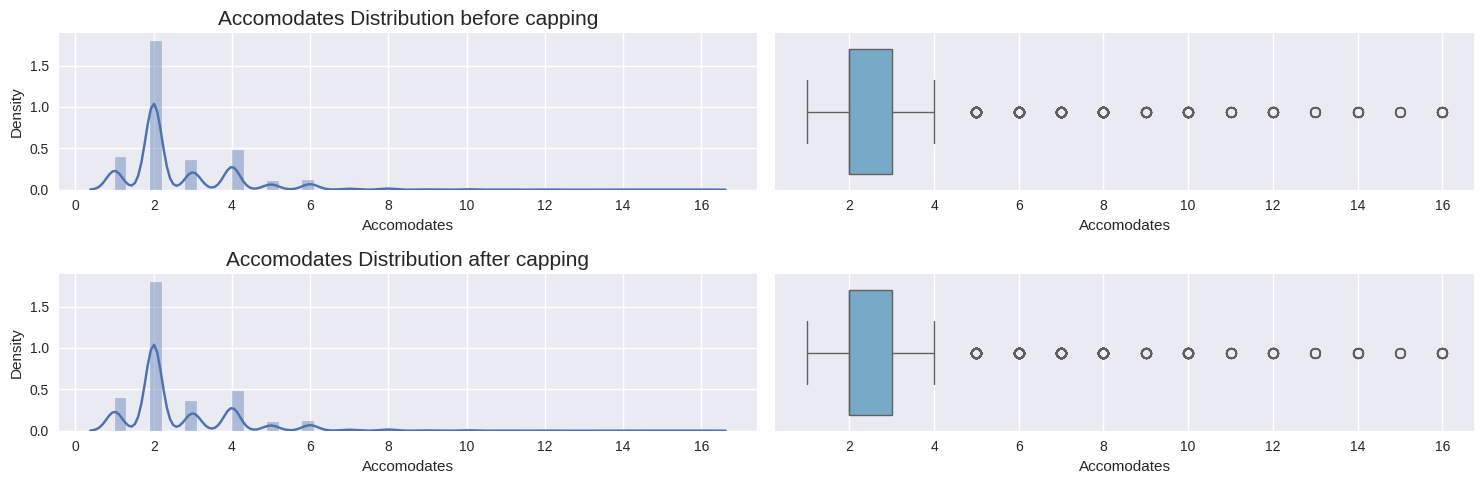

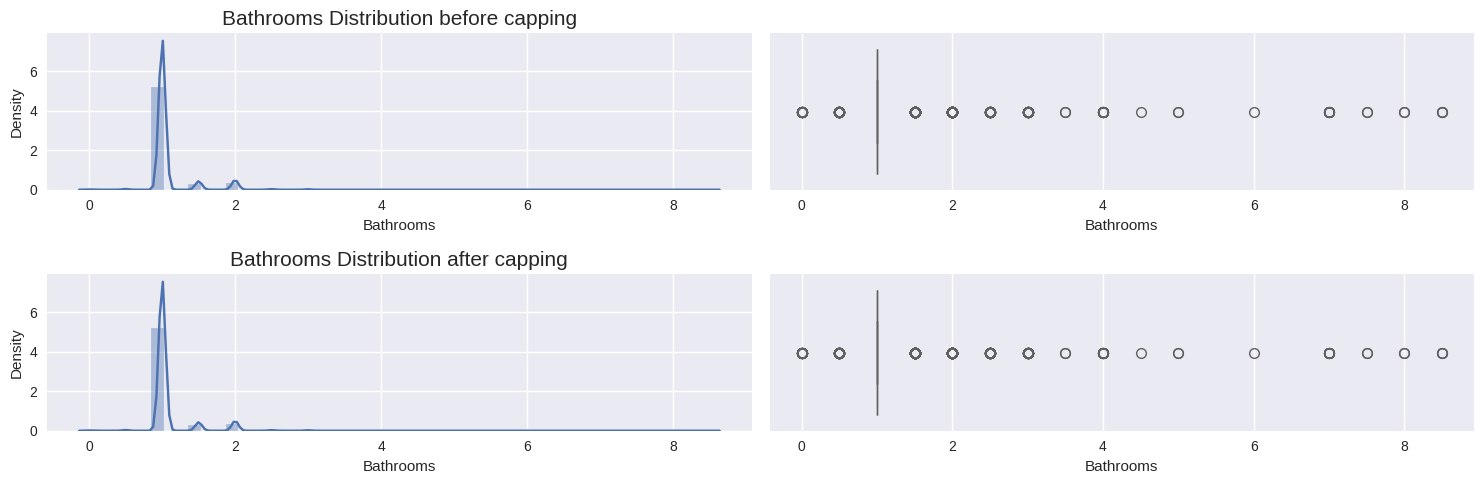

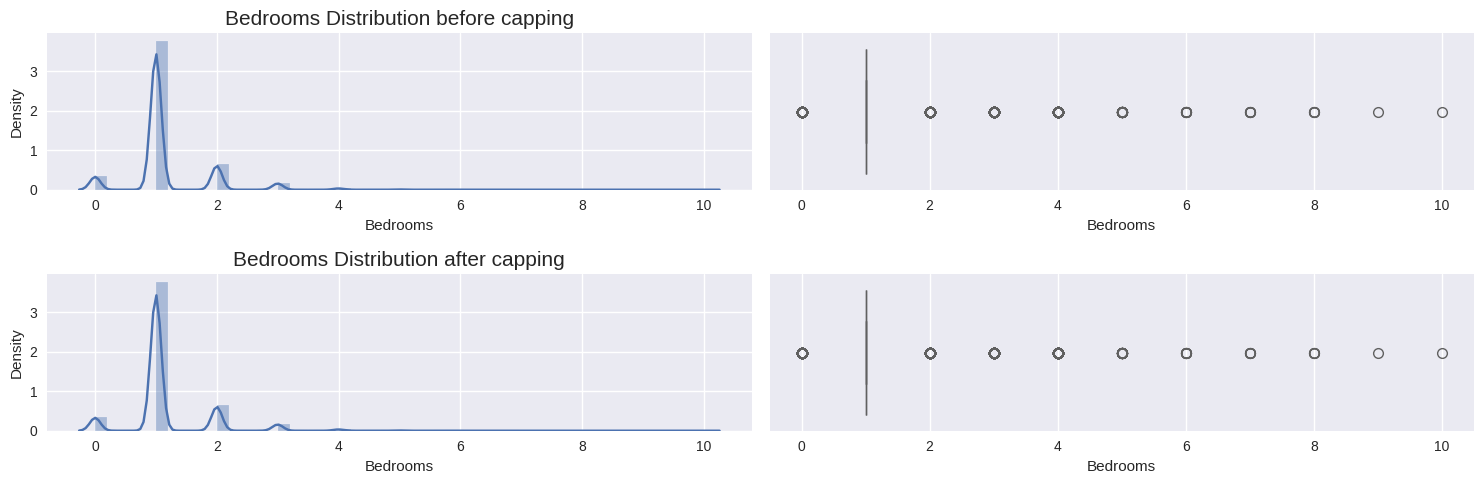

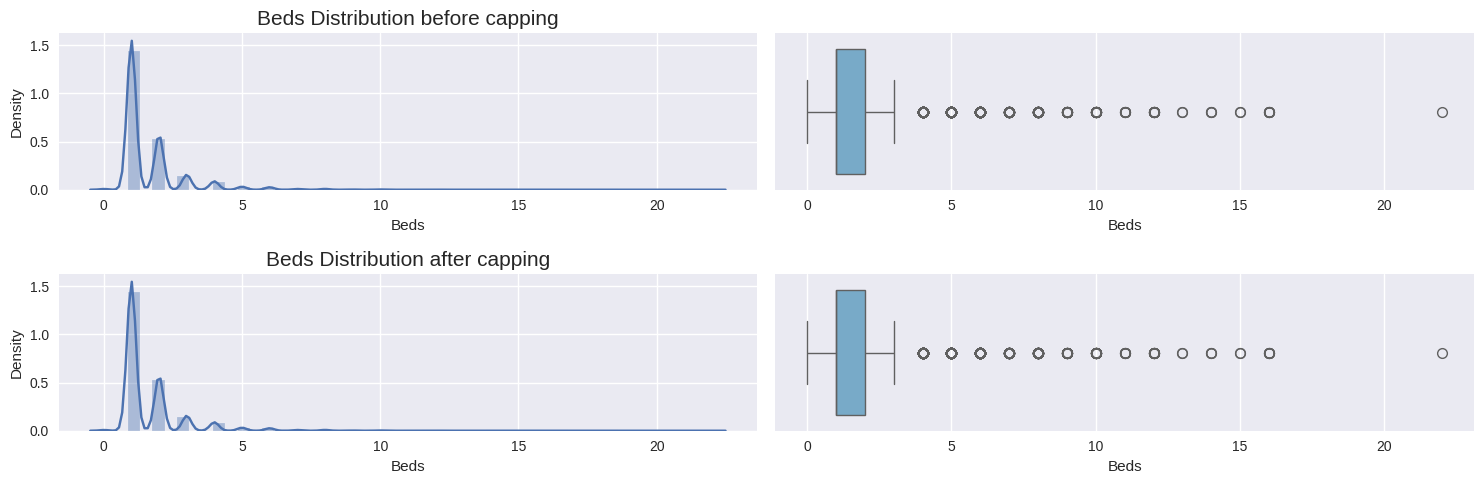

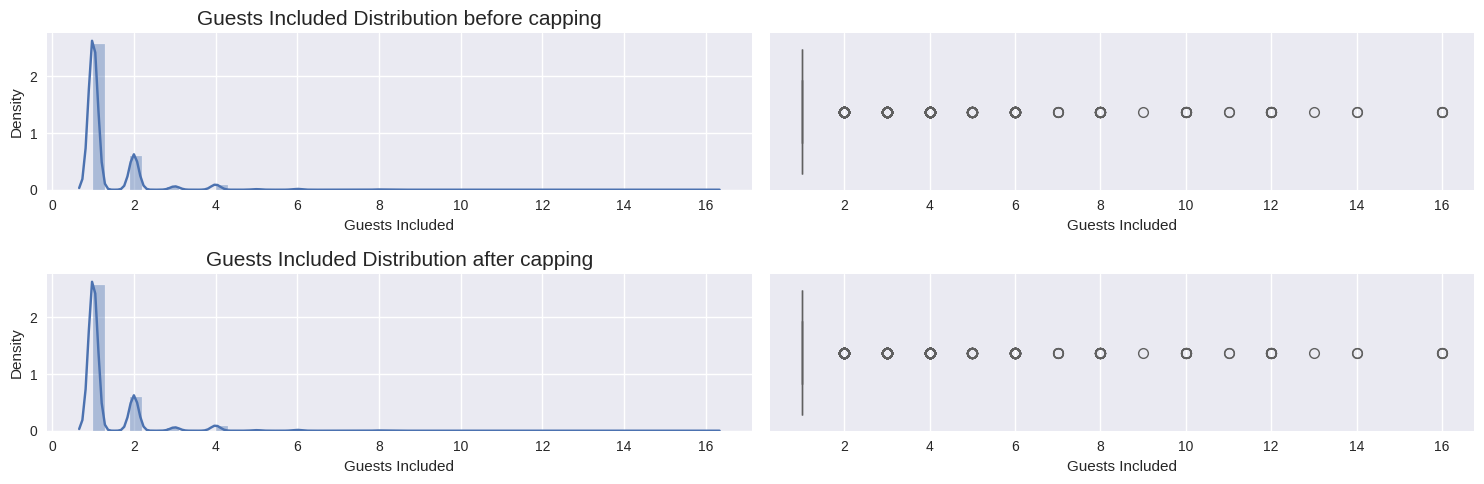

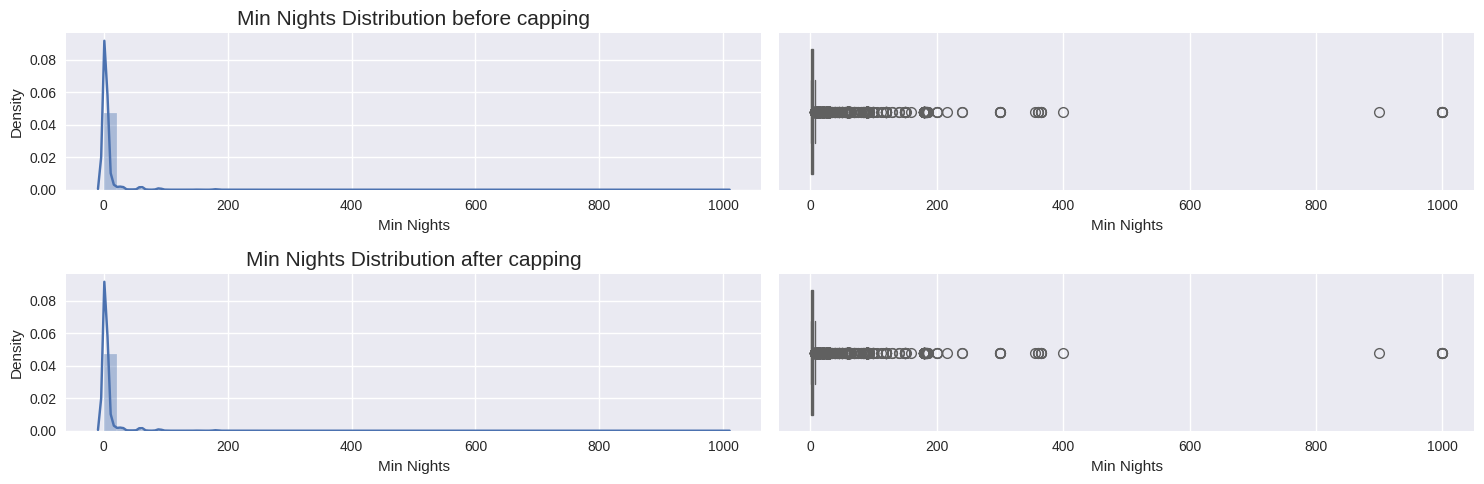

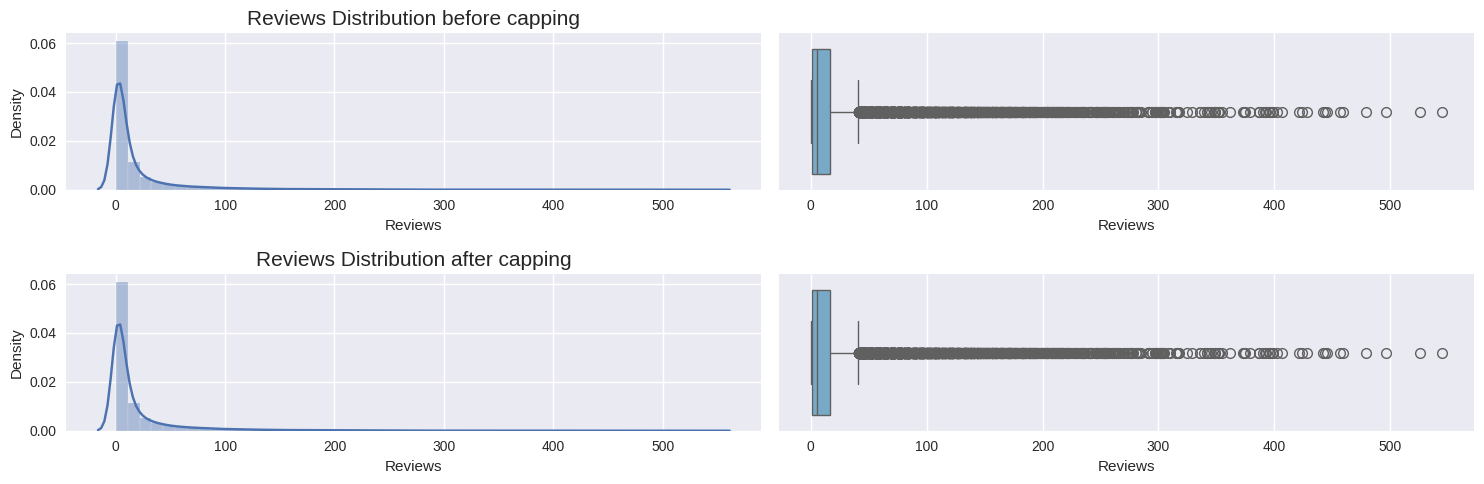

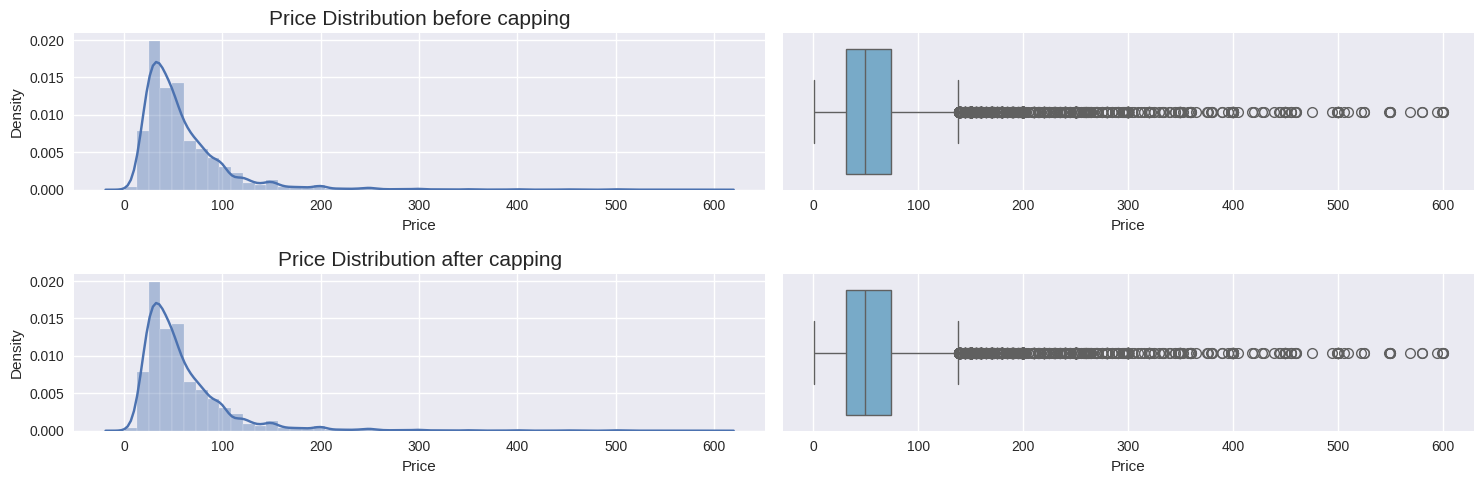

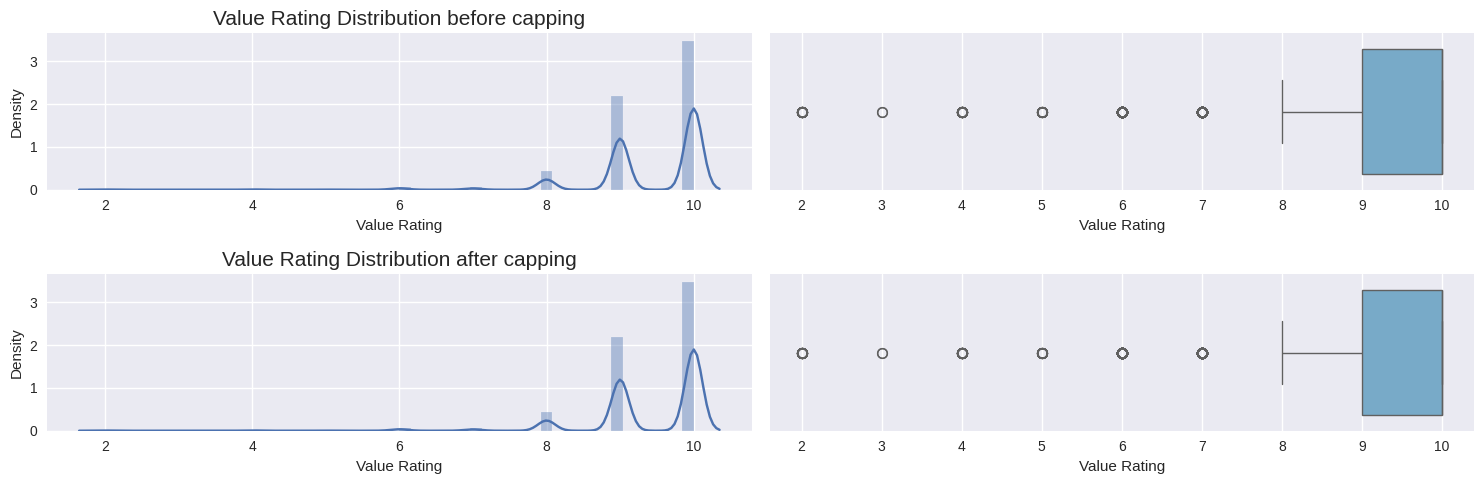

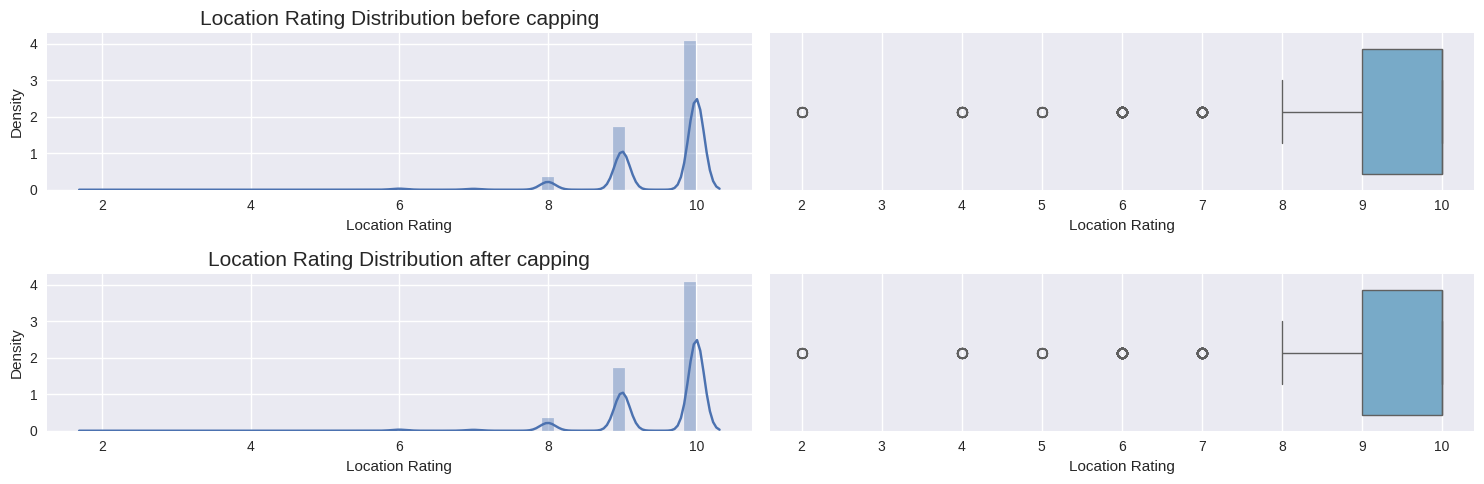

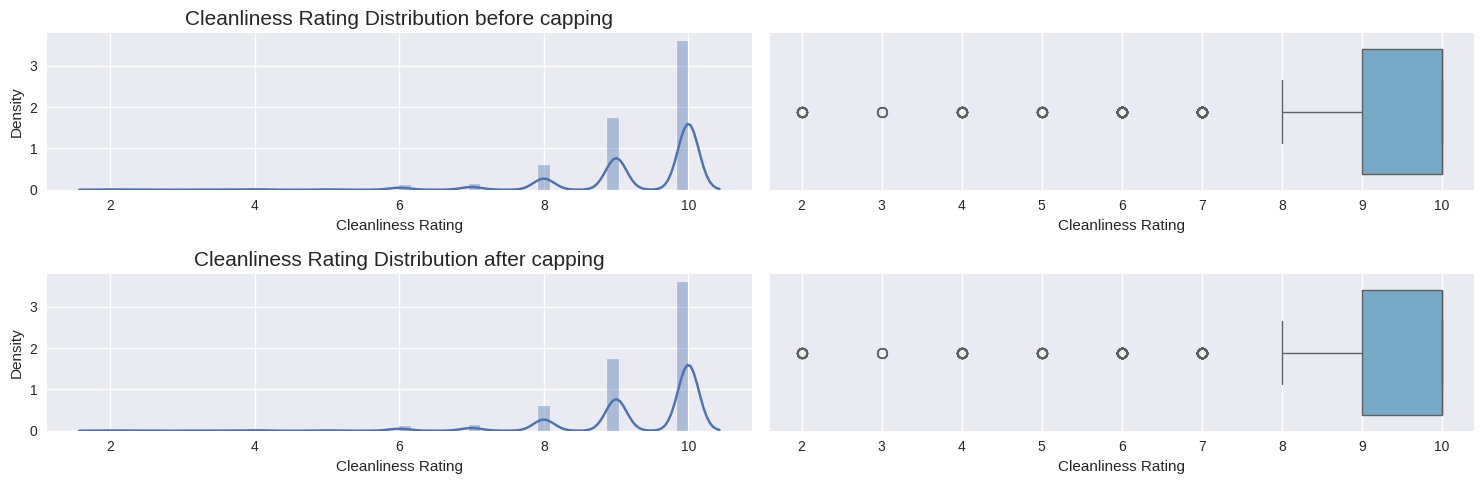

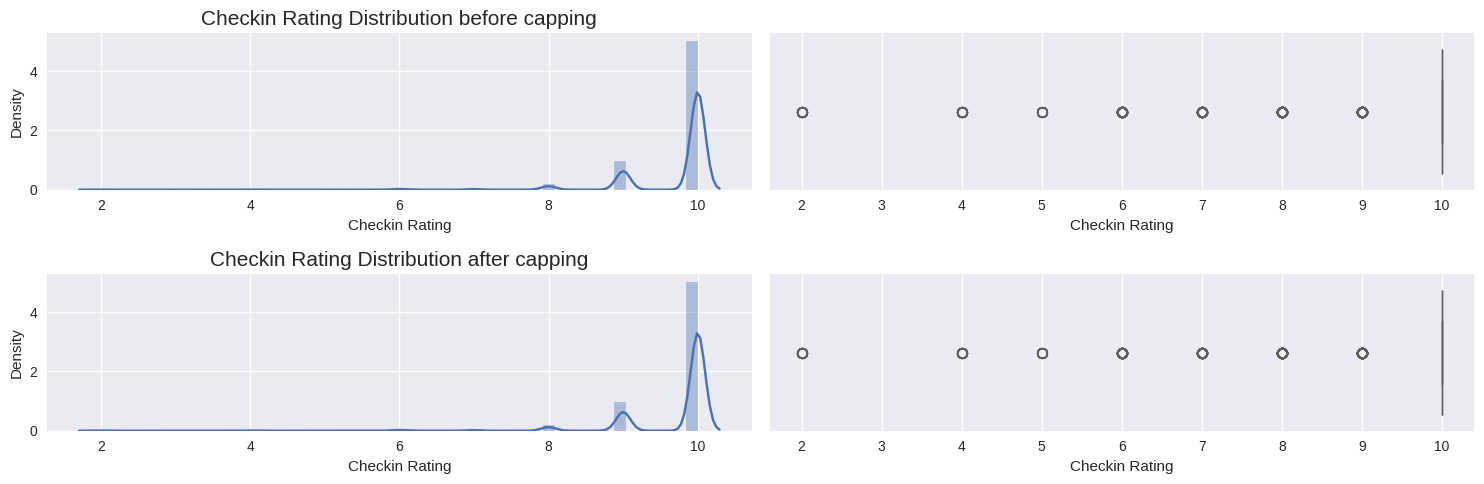

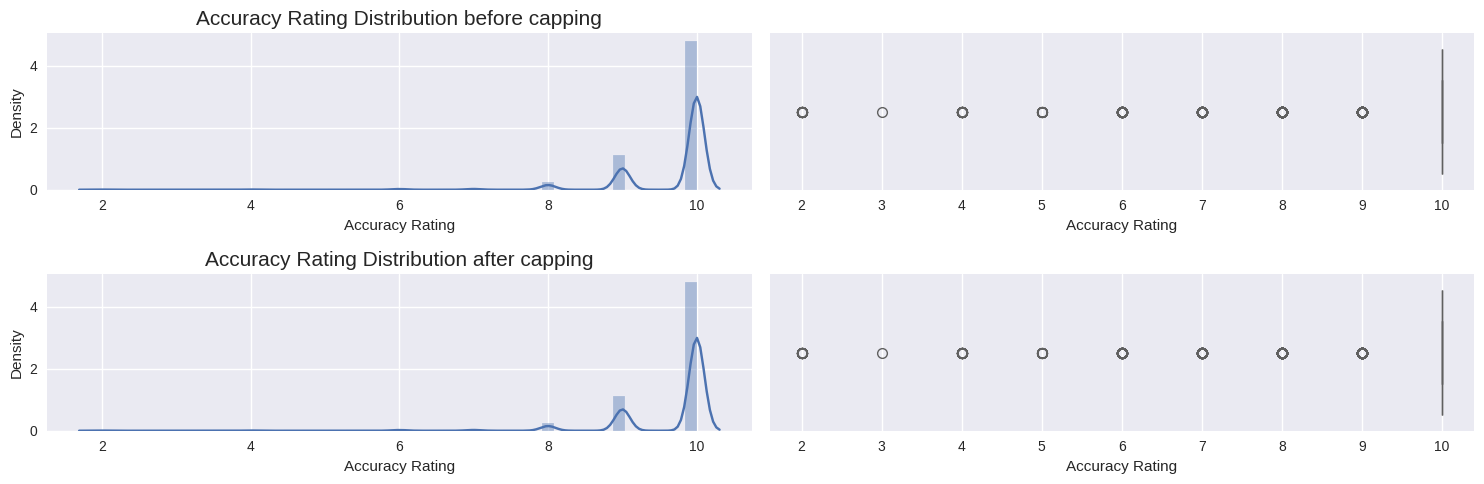

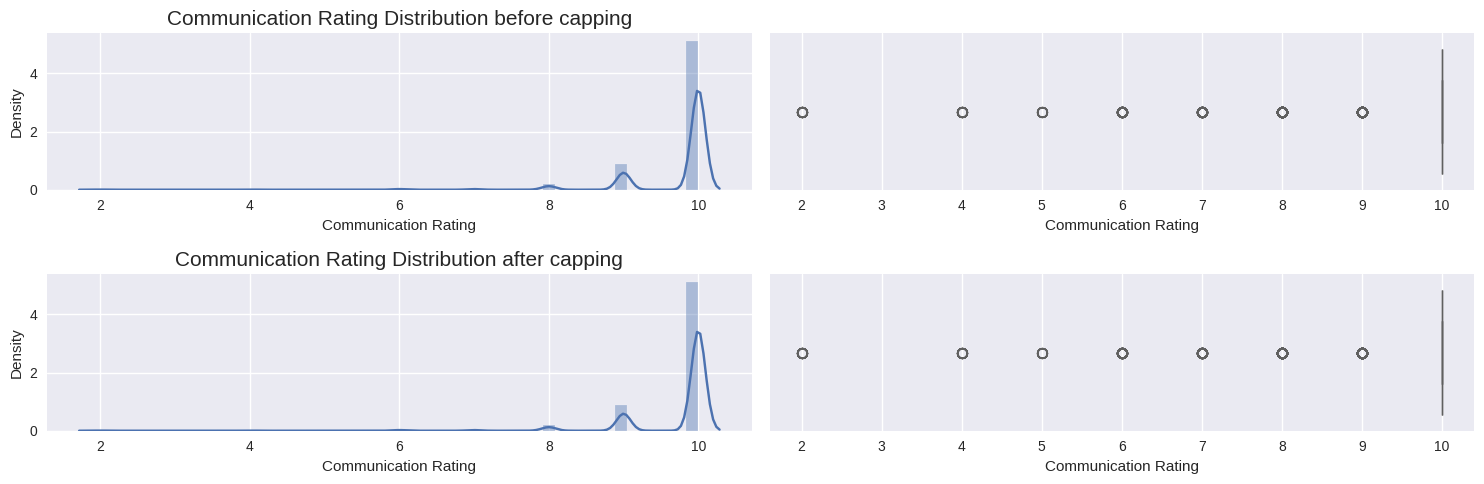

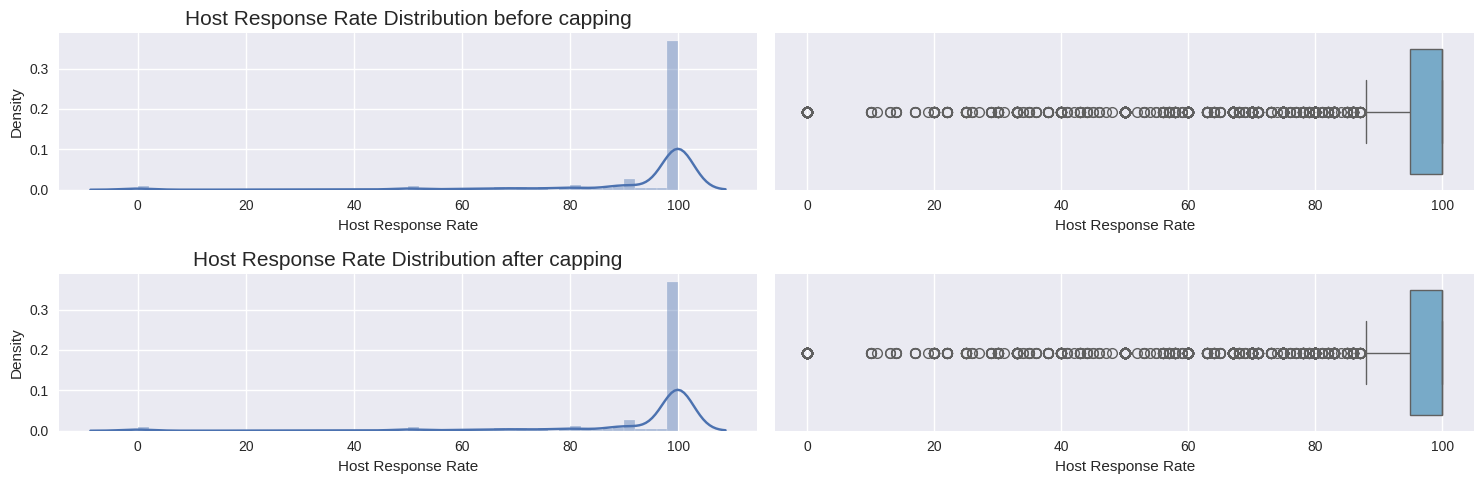

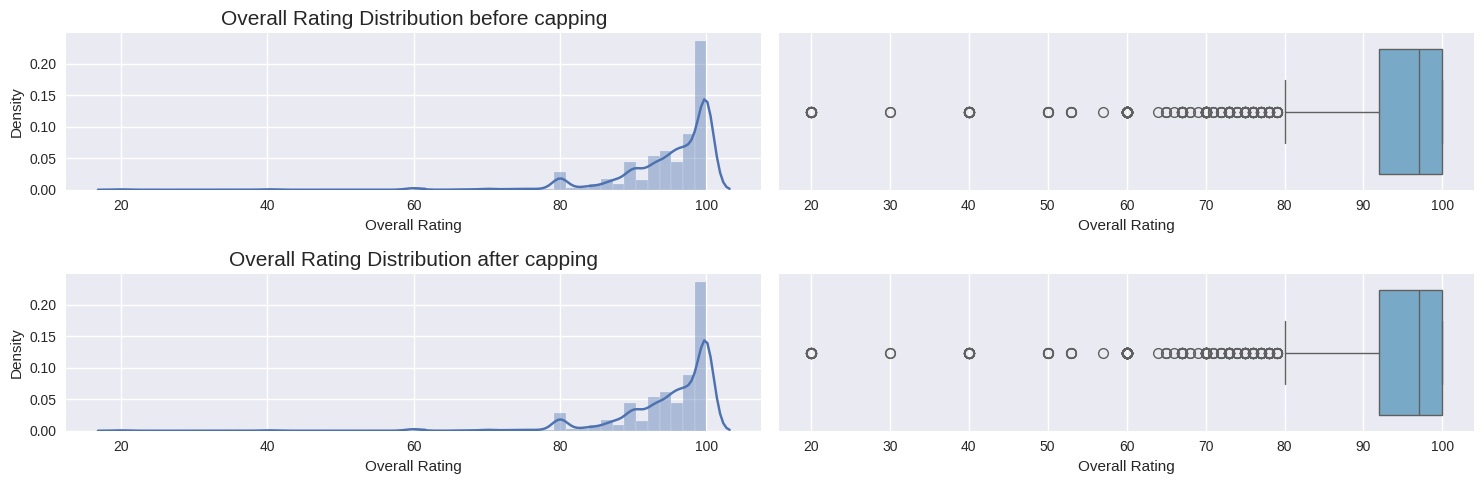

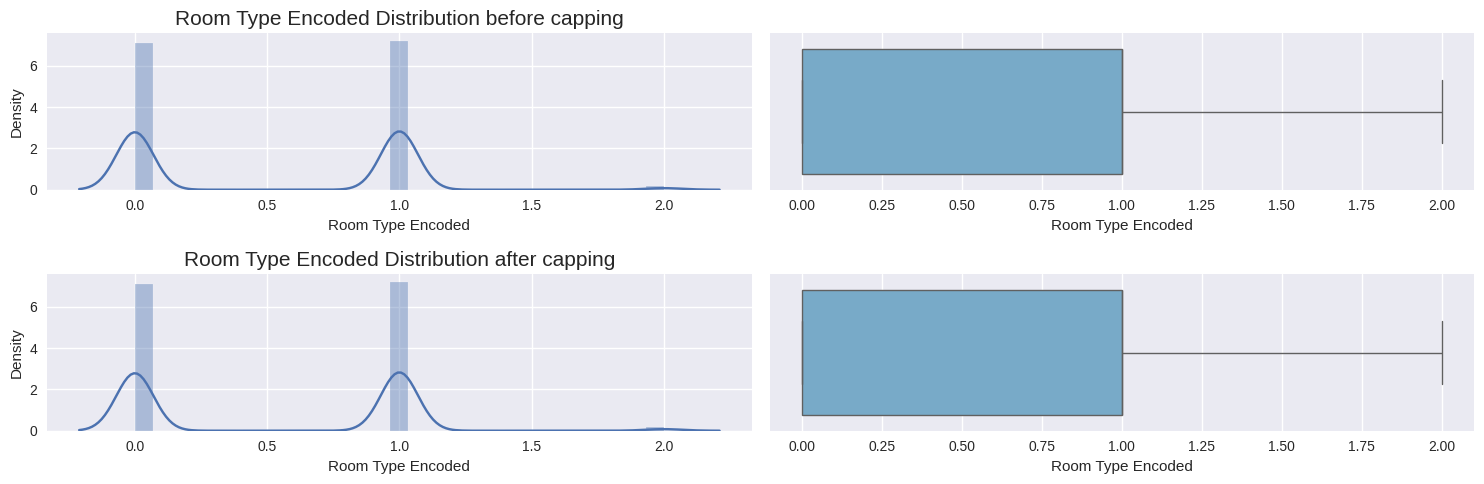

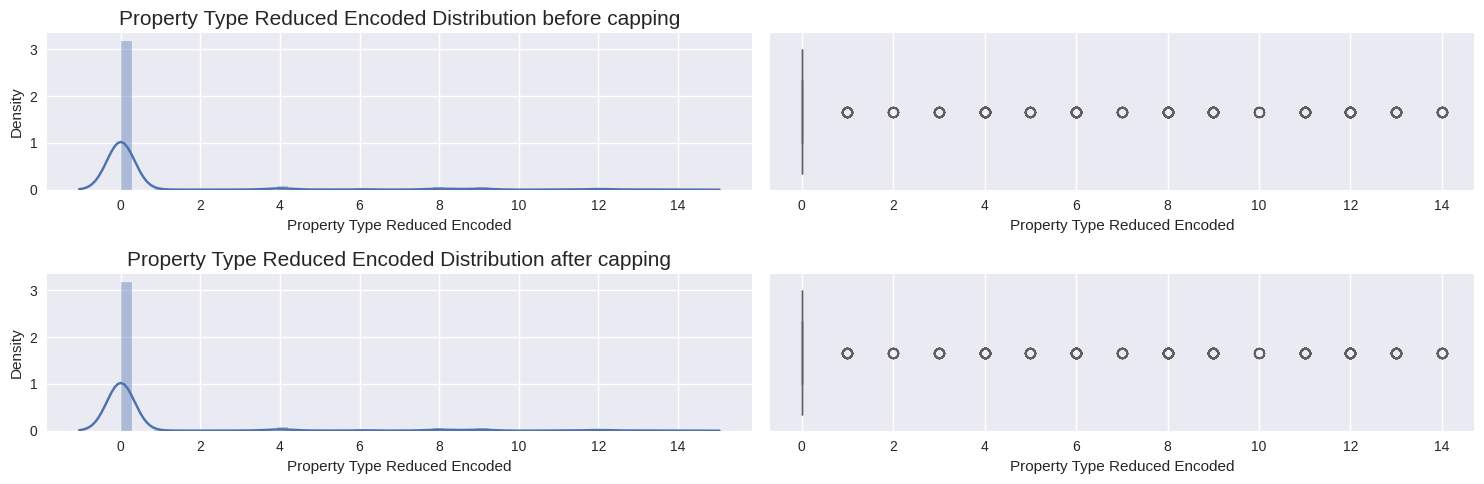

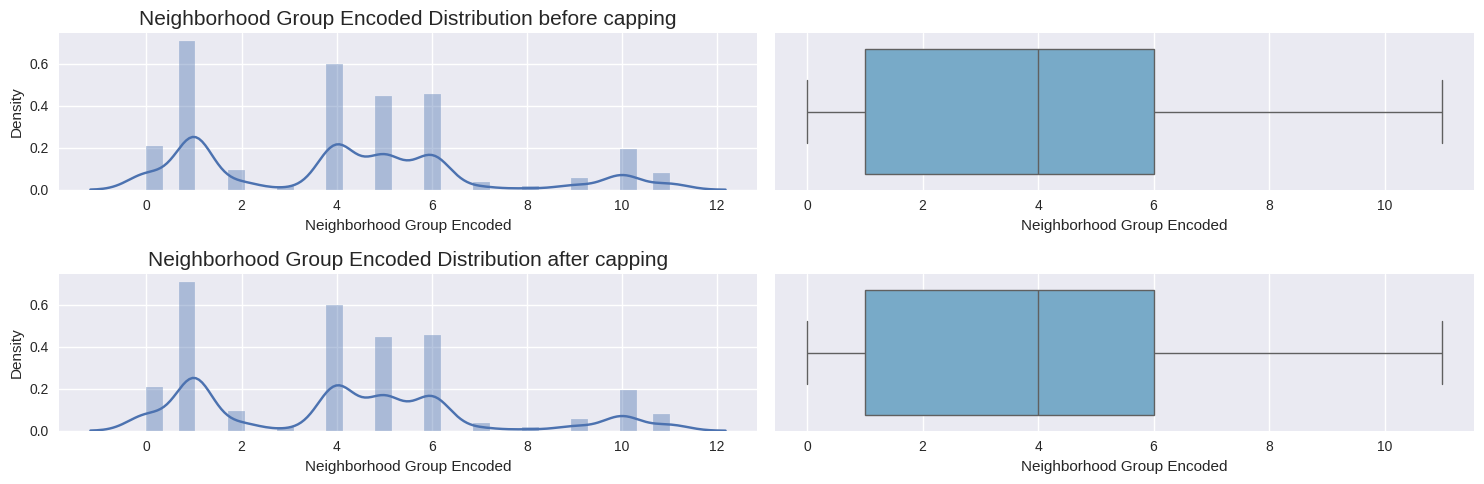

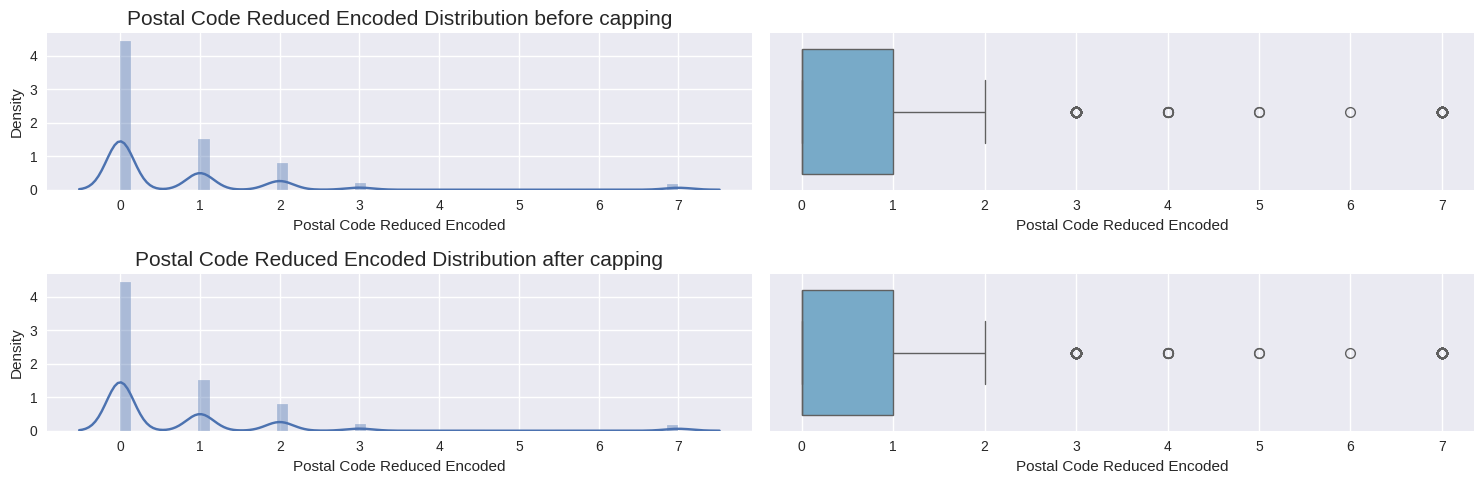

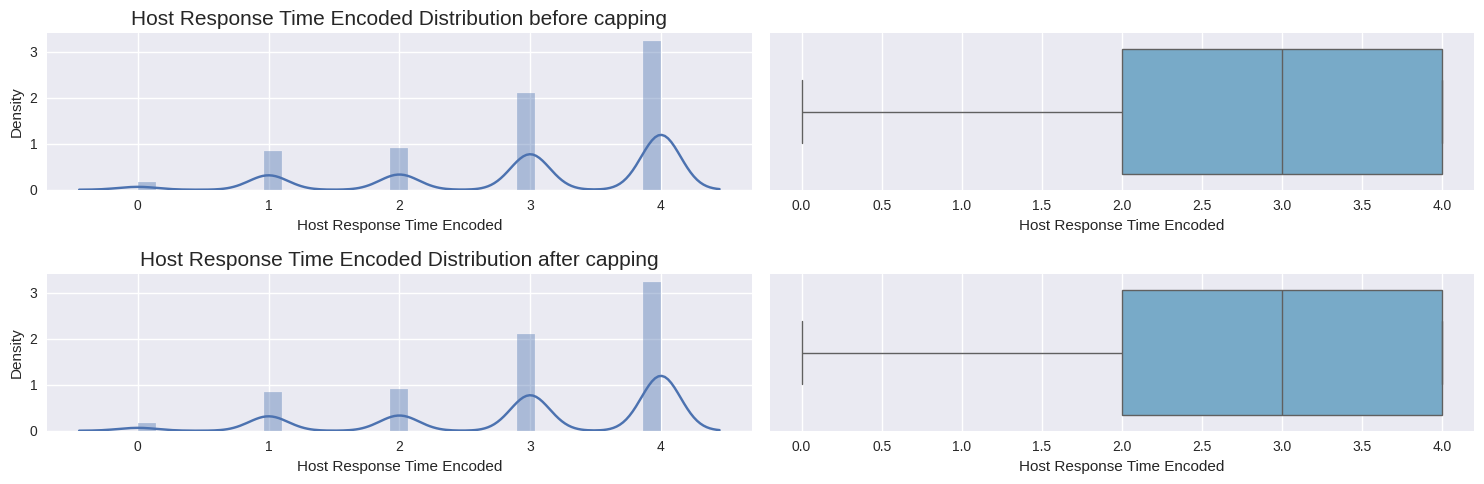

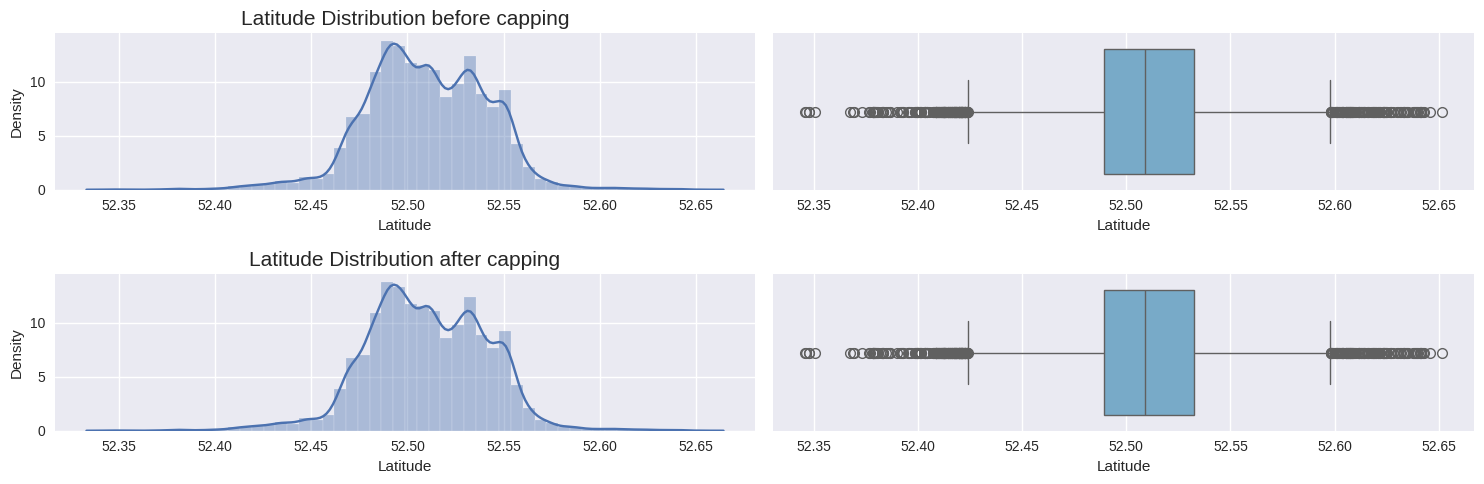

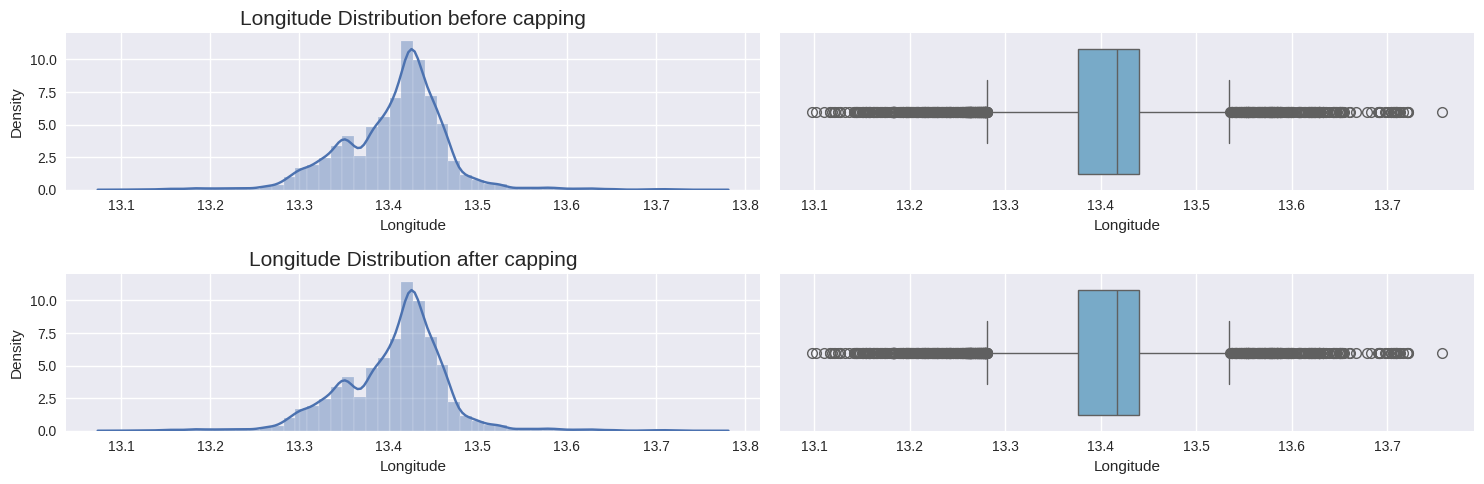

In [239]:
def dist_outliers(original_df, new, cols):
  for col in df_num_non_dummy:
      if col in cols:
        plt.figure(figsize=(15,5))

        plt.subplot(2,2,1)
        sns.distplot(original_df[col].dropna())
        plt.title('{} Distribution before capping'.format(col), fontsize=15)

        plt.subplot(2,2,2)
        sns.boxplot(x=original_df[col].dropna(), palette='Blues')
        plt.subplots_adjust(hspace = 0.6)

        plt.subplot(2,2,3)
        sns.distplot(new[col].dropna())
        plt.title('{} Distribution after capping'.format(col), fontsize=15)

        plt.subplot(2,2,4)
        sns.boxplot(x=new[col].dropna(), palette='Blues')
        plt.subplots_adjust(hspace = 0.6)

        plt.tight_layout()
        plt.show()

dist_outliers(df, temp, outliers_df.columns)

# to_pickle

In [233]:
df.to_pickle("/content/drive/My Drive/Airbnb/df_Feature_Engineering.pkl")

In [234]:
# df_Feature_Engineering = pd.read_pickle('/content/drive/My Drive/Airbnb/df_Feature_Engineering.pkl')
# df_Feature_Engineering.info()

# Candidate for Trush

In [235]:
# # Implementing Outlier Removal using the IQR Method
# def remove_outliers(df, column):
#     """Removes outliers based on IQR for a given column."""
#     Q1 = df[column].quantile(0.25)
#     Q3 = df[column].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# # Applying outlier removal to selected numerical columns
# cleaned_df = df.copy()
# # for col in ["Price", "Reviews", "Bedrooms", "Bathrooms", "Beds", "Accomodates"]:
# #     cleaned_df = remove_outliers(cleaned_df, col)

# # Displaying summary after outlier removal
# cleaned_df.head(5)